# Value at Risk (VaR) on a swaps Portfolio using Covariance Matrix

##### Imports

In [23]:
import sys
import os
# Adds the parent directory to the path so 'core' is visible
sys.path.append(os.path.abspath(".."))

from core.solvedcurve import SolvedCurve
from core.swap import Swap 
from core.dual import Dual 
from datetime import datetime, timedelta
from core.portfolio import Portfolio

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
from core.solvedcurve import SolvedCurve
from core.swap import Swap 
from core.dual import Dual 
from datetime import datetime, timedelta
from core.portfolio import Portfolio

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Setup a SolvedCurve and caliberate

In [24]:
nodes = {
    datetime(2022, 1, 1): Dual(1, {"v0": 1}),
    datetime(2024, 1, 1): Dual(1, {"v1": 1}),
    datetime(2027, 1, 1): Dual(1, {"v2": 1}),
    datetime(2032, 1, 1): Dual(1, {"v3": 1}),
    datetime(2052, 1, 1): Dual(1, {"v4": 1}),
}
swaps = {
    Swap(datetime(2022, 1, 1), 12*2, 12, 12): 1.20,
    Swap(datetime(2022, 1, 1), 12*5, 12, 12): 1.66,
    Swap(datetime(2022, 1, 1), 12*10, 12, 12): 1.93,
    Swap(datetime(2022, 1, 1), 12*30, 12, 12): 2.20,
}
s_cv = SolvedCurve(nodes=nodes, interpolation="log_linear", swaps=list(swaps.keys()), obj_rates=list(swaps.values()))
s_cv.iterate()

'tolerance reached (levenberg_marquardt) after 12 iterations. f:1.43219494212483e-18'

### Build covariance matrix using Historical data

In [25]:
historical_rates = pd.DataFrame({
    "2Y": [1.199, 1.228, 1.210, 1.215, 1.203, 1.159, 1.175, 1.188, 1.159, 1.100],
    "5Y": [1.663, 1.696, 1.665, 1.680, 1.677, 1.657, 1.673, 1.676, 1.653, 1.600],
    "10Y": [1.928, 1.945, 1.934, 1.93, 1.934, 1.931, 1.958, 1.972, 1.932, 1.900],
    "30Y": [2.201, 2.217, 2.228, 2.239, 2.226, 2.235, 2.242, 2.236, 2.22, 2.200],
})
historical_rates

,2Y,5Y,10Y,30Y
0,1.199,1.663,1.928,2.201
1,1.228,1.696,1.945,2.217
2,1.210,1.665,1.934,2.228
3,1.215,1.680,1.930,2.239
4,1.203,1.677,1.934,2.226
5,1.159,1.657,1.931,2.235
6,1.175,1.673,1.958,2.242
7,1.188,1.676,1.972,2.236
8,1.159,1.653,1.932,2.220
9,1.100,1.600,1.900,2.200


In [26]:
daily_changes_bp = historical_rates.diff(periods=-1) * 100
daily_changes_bp

,2Y,5Y,10Y,30Y
0,-2.9,-3.3,-1.7,-1.6
1,1.8,3.1,1.1,-1.1
2,-0.5,-1.5,0.4,-1.1
3,1.2,0.3,-0.4,1.3
4,4.4,2.0,0.3,-0.9
5,-1.6,-1.6,-2.7,-0.7
6,-1.3,-0.3,-1.4,0.6
7,2.9,2.3,4.0,1.6
8,5.9,5.3,3.2,2.0
9,NaN,NaN,NaN,NaN


In [27]:
Q = daily_changes_bp.cov()
Q

,2Y,5Y,10Y,30Y
2Y,8.66000,7.3775,5.136250,2.185000
5Y,7.37750,7.3075,4.730000,2.157500
10Y,5.13625,4.7300,4.891111,1.762361
30Y,2.18500,2.1575,1.762361,1.861111


### Create a portfolio and calculate portfolio loss for different confidence intervals

In [28]:
swaps = [
    Swap(datetime(2022, 1, 1), 12 * 2, 12, 12, fixed_rate=1.20, notional=-50.9e6),
    Swap(datetime(2022, 1, 1), 12 * 5, 12, 12, fixed_rate=1.66, notional=5.23e6),
    Swap(datetime(2022, 1, 1), 12 * 10, 12, 12, fixed_rate=1.93, notional=11.0e6),
    Swap(datetime(2022, 1, 1), 12 * 20, 12, 12, fixed_rate=2.20, notional=-1.81e6),
]

portfolio = Portfolio(objects=swaps)
print(f'{portfolio.npv(s_cv).real=}')
print(f'{portfolio.risk(s_cv).real=}')

print(f'Portfolio standard deviation: c = {portfolio.covar(s_cv, Q)=}')

portfolio.npv(s_cv).real=19610.615707904602
portfolio.risk(s_cv).real=array([[-10000.40539923],
       [  2498.31245839],
       [  9281.40972086],
       [ -2252.9308566 ]])
Portfolio standard deviation: c = portfolio.covar(s_cv, Q)=15497.774550623128


### Portfolio loss for few confidence intervals (Assuming normal distribution with u=0 for price changes)

In [29]:
key_x = [50, 84.13447, 90, 95, 99]
key_y = [portfolio.covar(s_cv, Q, alpha=(1-xi/100)) for xi in key_x]

for x, covar_x in zip(key_x, key_y):
    print(f'{x}% of the time loss <= {covar_x}')

50% of the time loss <= 0.0
84.13447% of the time loss <= 15497.77160001897
90% of the time loss <= 19861.197237808334
95% of the time loss <= 25491.570679268672
99% of the time loss <= 36053.21487820636


### Plot portfolio change with confidence interval

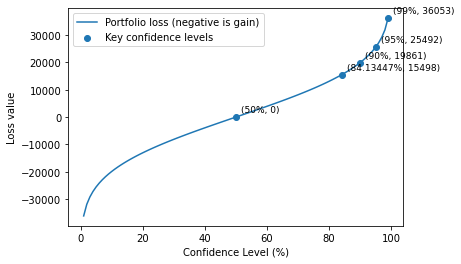

In [30]:
x = [i for i in range(0, 100)]
y = [portfolio.covar(s_cv, Q, alpha=(1-xi/100)) for xi in x]

# annotate key_x, covar values
for xi, covar_x in zip(key_x, key_y):
    plt.annotate(f'({xi}%, {covar_x:.0f})', 
                 xy=(xi, covar_x), 
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=9)

plt.plot(np.array(x), np.array(y), label='Portfolio loss (negative is gain)')
plt.scatter(key_x, key_y, label='Key confidence levels')

plt.xlabel('Confidence Level (%)')
plt.ylabel('Loss value')


plt.legend()
plt.show()